<a href="https://colab.research.google.com/github/fahad15fede/Assignment-AI-ML/blob/main/Logistic_Regression_Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print("Unique values in 'Glucose' before replacement:")
print(df['Glucose'].unique())

print("\nUnique values in 'BloodPressure' before replacement:")
print(df['BloodPressure'].unique())

print("\nUnique values in 'Insulin' before replacement:")
print(df['Insulin'].unique())

Unique values in 'Glucose' before replacement:
[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]

Unique values in 'BloodPressure' before replacement:
[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]

Unique values in 'Insulin' before replacement:
[  0  94 168  88 543 846 175 230  83  96 235 146 115 140 110 245  54 192
 207  70 240  82  36  23 300 342 

In [ ]:
import numpy as np

df_pipeline = df.copy()

# Replace 0s with NaN for specific columns in the copied DataFrame
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_pipeline[col] = df_pipeline[col].replace(0, np.nan)

print('First 5 rows of DataFrame after replacing 0s with NaN:')
display(df_pipeline.head())

First 5 rows of DataFrame after replacing 0s with NaN:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y) from the prepared DataFrame
X = df_pipeline.drop('Outcome', axis=1)
y = df_pipeline['Outcome']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the pipeline
# Step 1: Impute missing values (NaNs, originally 0s) with the median
# Step 2: Scale the features
# Step 3: Apply Logistic Regression
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression())
])

print('ML Pipeline created successfully:')
display(pipe)

ML Pipeline created successfully:


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression())])

## Model Training (with Pipeline)

In [ ]:
# Train the pipeline
pipe.fit(X_train, y_train)

print('Pipeline trained successfully.')

Pipeline trained successfully.


## Model Evaluation (with Pipeline)

Accuracy: 0.7532

Confusion Matrix:


array([[82, 17],
       [21, 34]])

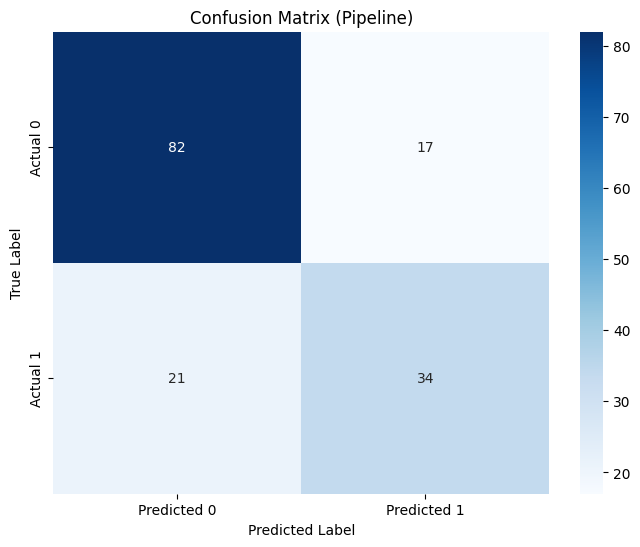


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test data using the trained pipeline
y_pred = pipe.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
display(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Pipeline)')
plt.show()

# Display classification report
class_report = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(class_report)

## Model Saving (Pipeline)

In [ ]:
import pickle

# Save the trained pipeline to a .pkl file
pipeline_filename = 'logistic_regression_pipeline.pkl'
with open(pipeline_filename, 'wb') as file:
    pickle.dump(pipe, file)

print(f'Pipeline successfully saved to {pipeline_filename}')

# Optionally, load the pipeline to verify
# with open(pipeline_filename, 'rb') as file:
#     loaded_pipe = pickle.load(file)
# print(f'Loaded pipeline type: {type(loaded_pipe)}')


Pipeline successfully saved to logistic_regression_pipeline.pkl
